In [47]:
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
import matplotlib.pyplot as plt
titanic = pd.read_csv('./Titanic.csv')

# Display the first few rows of the dataframe
titanic.head()

,Unnamed: 0,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1st,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.337494,B5,Southampton,2,NaN,"St Louis, MO"
1,2,1st,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.550003,C22 C26,Southampton,11,NaN,"Montreal, PQ / Chesterville, ON"
2,3,1st,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,4,1st,0,"Allison, Mr. Hudson Joshua Crei",male,30.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,5,1st,0,"Allison, Mrs. Hudson J C (Bessi",female,25.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,NaN,"Montreal, PQ / Chesterville, ON"


# Step 1

In [48]:
def QuantileBinning(feature, bin_number):
    """
    This function takes a numerical feature and the number of bins, and
    returns the feature binned into quantile-based bins.

    Parameters:
    - feature (pandas.Series): The numerical feature to be binned.
    - bin_number (int): The number of quantile bins.

    Returns:
    - pandas.Series: A series of discrete features binned by quantile.
    """
    # Use qcut to create quantile-based bins for the feature
    # If there are fewer unique values than bins, qcut could throw an error.
    # 'duplicates' parameter handles this by dropping redundant bins.
    return pd.qcut(feature, q=bin_number, labels=False, duplicates='drop')

# One example
feature_test = pd.DataFrame(np.random.rand(100),  columns=['Column_A'])
feature_test_discrete = QuantileBinning(feature_test['Column_A'], 10)

def label_encoder(feature):
    unique_labels = pd.unique(feature)
    label_to_int = {label: idx for idx, label in enumerate(unique_labels)}
    transformed_feature = np.array([label_to_int[label] for label in feature])
    return transformed_feature

In [49]:
# Filter the titanic dataframe to select specific columns
data = titanic.filter(['pclass', 'sex', 'age', 'sibsp', 'survived'], axis = 1)
# Display the first few rows of the dataframe
data.head()

,pclass,sex,age,sibsp,survived
0,1st,female,29.0000,0,1
1,1st,male,0.9167,1,1
2,1st,female,2.0000,1,0
3,1st,male,30.0000,1,0
4,1st,female,25.0000,1,0


In [50]:
# Check for the number of missing values of each feature in the filtered dataframe
data.isna().sum()

pclass        0
sex           0
age         263
sibsp         0
survived      0
dtype: int64

In [51]:
# Import the SimpleImputer class
from sklearn.impute import SimpleImputer

# Create an instance of SimpleImputer that replaces missing values with the mean
mean_imputer = SimpleImputer(strategy='mean')

# Apply the mean imputer to the 'age' column (index 2) to fill missing values
data.iloc[:, 2] = mean_imputer.fit_transform(data.iloc[:, 2:3])

# Check for the number of missing values of each feature in the filtered dataframe
data.isna().sum()

pclass      0
sex         0
age         0
sibsp       0
survived    0
dtype: int64

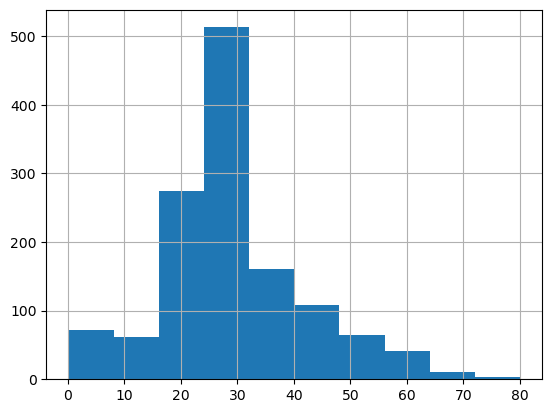

In [52]:
data['age'].hist()
plt.show()

In [53]:
# Bin the 'age' feature into 20 quantile based bins
data['age'] = QuantileBinning(data['age'], 20)


# Encode the labels of categorical features to integer labels
data['pclass'] = label_encoder(data['pclass'])
data['sex'] = label_encoder(data['sex'])
data['sibsp'] = label_encoder(data['sibsp'])
data['survived'] = label_encoder(data['survived'])

In [54]:
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% test sets
train, test = train_test_split(data, test_size = 0.2, random_state = 42)

In [55]:
train.head()

,pclass,sex,age,sibsp,survived
772,2,1,2,0,1
543,1,1,12,0,1
289,0,0,2,0,0
10,0,1,14,1,1
147,0,1,8,0,1


In [56]:
test.head()

,pclass,sex,age,sibsp,survived
1148,2,1,11,0,1
1049,2,1,3,1,0
982,2,1,8,0,1
808,2,1,8,0,1
1195,2,1,8,0,1


# Step 2

In [57]:
import math

# define your entropy function and information gain function
def entropy(dataset) :

  # Initialize a list to hold probabilities of each unique label
  label_probability = []

  # Store entropy values
  e = 0

  # Get unique labels from the 'survived' column
  unique_labels = pd.unique(dataset['survived'])

  # Calculate the probability of each unique label
  for l in unique_labels :
    label_probability.append(dataset['survived'].value_counts()[l] / len(dataset['survived']))

  # Calculate the entropy using the probabilities
  for p in label_probability :
    e -= p * (math.log(p, 2))

  return e



def information_gain(dataset, feature) :
  # Initialize a list to hold the weighted entropy for each split
  weighted_entropy_of_split = []

  # Get unique values (splits) of the specified feature
  splits = pd.unique(dataset[feature])

  # Calculate the weighted entropy for each split
  for s in splits :
    df = dataset[dataset[feature] == s]
    weighted_entropy_of_split.append( ( len(df['survived']) / len(dataset['survived']) ) * entropy(df) )

  # Calculate the information gain by subtracting the weighted entropy of the splits from the total entropy
  info_gain = entropy(dataset) - sum(weighted_entropy_of_split)

  return info_gain




# Calculate Information Gain for each feature in the training set
info_gains = {}

for f in train.columns[:-1] :
  info_gains[f] = information_gain(train, f)


In [58]:
info_gains

{'pclass': 0.06353574221838054,
 'sex': 0.20968297666244173,
 'age': 0.028245579438773816,
 'sibsp': 0.02531230300308851}

So the first split should be "sex"

# Step 3

In [59]:
X_train = train.filter(['pclass', 'sex', 'age', 'sibsp'], axis = 1)
y_train = train.filter(['survived'], axis = 1)

X_test = test.filter(['pclass', 'sex', 'age', 'sibsp'], axis = 1)
y_test = test.filter(['survived'], axis = 1)

[Text(0.3697916666666667, 0.9375, 'sex <= 0.5\ngini = 0.463\nsamples = 1047\nvalue = [382, 665]\nclass = Survived'),
 Text(0.125, 0.8125, 'pclass <= 1.5\ngini = 0.409\nsamples = 370\nvalue = [264, 106]\nclass = Not Survived'),
 Text(0.24739583333333334, 0.875, 'True  '),
 Text(0.08333333333333333, 0.6875, 'gini = 0.124\nsamples = 195\nvalue = [182, 13]\nclass = Not Survived'),
 Text(0.16666666666666666, 0.6875, 'sibsp <= 2.5\ngini = 0.498\nsamples = 175\nvalue = [82.0, 93.0]\nclass = Survived'),
 Text(0.08333333333333333, 0.5625, 'age <= 1.5\ngini = 0.5\nsamples = 157\nvalue = [79, 78]\nclass = Not Survived'),
 Text(0.041666666666666664, 0.4375, 'gini = 0.417\nsamples = 27\nvalue = [19, 8]\nclass = Not Survived'),
 Text(0.125, 0.4375, 'sibsp <= 0.5\ngini = 0.497\nsamples = 130\nvalue = [60, 70]\nclass = Survived'),
 Text(0.08333333333333333, 0.3125, 'gini = 0.499\nsamples = 89\nvalue = [46.0, 43.0]\nclass = Not Survived'),
 Text(0.16666666666666666, 0.3125, 'age <= 7.5\ngini = 0.45\nsa

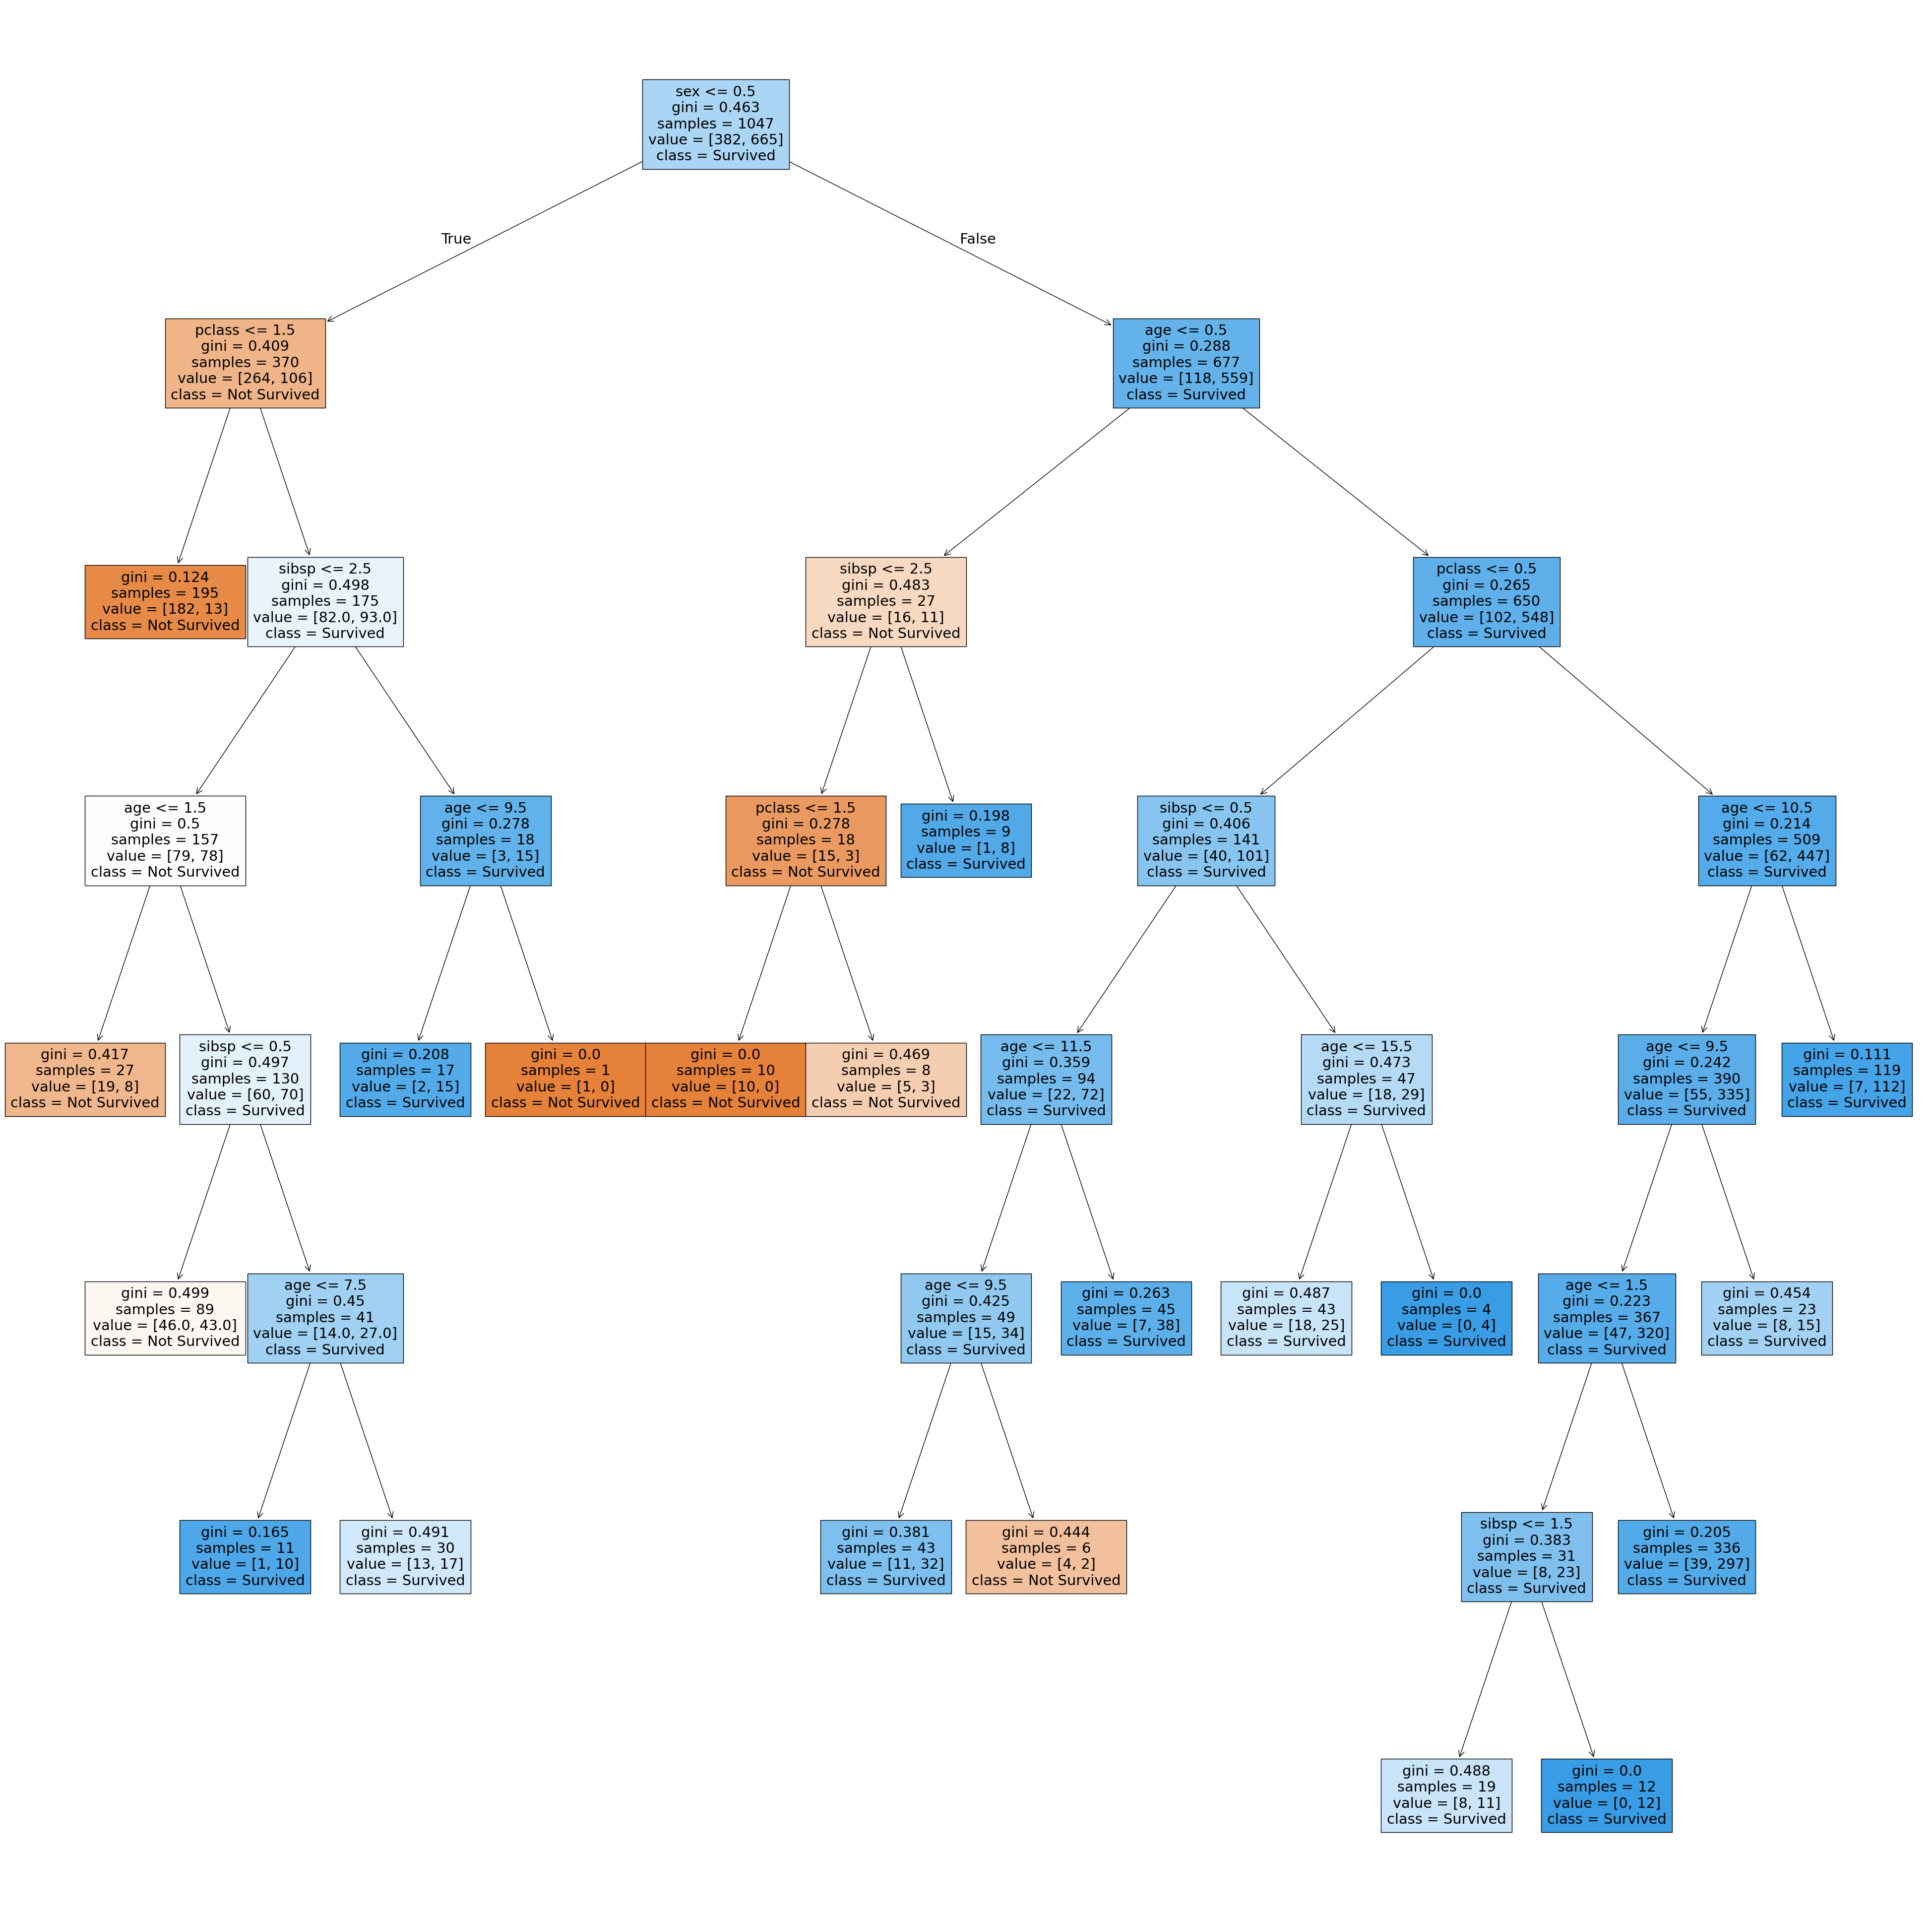

In [60]:
from sklearn.tree import DecisionTreeClassifier, plot_tree #sklearn.metrics is not imported !!!

# Instantiate the DecisionTreeClassifier
clf = DecisionTreeClassifier(max_leaf_nodes = 20, random_state = 20034297)


# Fit the decision tree model
clf.fit(X_train, y_train)


# Get the predictions for the test dataset
y_dt_pred = clf.predict(X_test)


# Plot the full decision tree
fig = plt.figure(figsize=(50,50))
plot_tree(clf, feature_names = list(X_train.columns), class_names = ['Not Survived', 'Survived'], filled = True)


In [61]:
# Define your performance metrics including accuracy, precision, recall and F1-scorre
def confusion_matrix(true, prediction):
    # Initialize counts for true positives (tp), true negatives (tn),
    # false positives (fp), and false negatives (fn)
    tp = 0
    tn = 0
    fp = 0
    fn = 0

    # Reshape the true labels to match the shape of predictions
    true = np.array(true).reshape(np.array(prediction).shape)
    pred = np.array(prediction)

    # Iterate through the true and predicted values to calculate counts
    for i in range(len(true)):
        if true[i] == prediction[i]:
            if true[i] == 0:
                tn += 1  # True negative
            else:
                tp += 1  # True positive
        else:
            if true[i] == 0:
                fp += 1  # False positive
            else:
                fn += 1  # False negative

    # Create a confusion matrix DataFrame
    matrix = pd.DataFrame(index=['Actual Negative', 'Actual Positive'],
                          columns=['Predicted Negative', 'Predicted Positive'])
    matrix.iloc[0, 0] = tn
    matrix.iloc[0, 1] = fp
    matrix.iloc[1, 0] = fn
    matrix.iloc[1, 1] = tp

    return matrix  # Return the confusion matrix


def accuracy(true, prediction):
    # Initialize a count of correct predictions
    count = 0

    # Reshape the true labels to match the shape of predictions
    true = np.array(true).reshape(np.array(prediction).shape)
    pred = np.array(prediction)

    # Iterate through the true and predicted values to count correct predictions
    for i in range(len(true)):
        if true[i] == prediction[i]:
            count += 1  # Increment count for correct prediction

    # Calculate accuracy as the ratio of correct predictions to total predictions
    accuracy = count / len(true)

    return accuracy  # Return the calculated accuracy


def precision(true, prediction):
    # Initialize counts for true positives (tp) and false positives (fp)
    tp = 0
    fp = 0

    # Reshape the true labels to match the shape of predictions
    true = np.array(true).reshape(np.array(prediction).shape)
    pred = np.array(prediction)

    # Iterate through the true and predicted values to calculate tp and fp
    for i in range(len(true)):
        if true[i] == prediction[i]:
            if true[i] == 1:
                tp += 1  # Increment tp for correct positive prediction
        else:
            if true[i] == 0:
                fp += 1  # Increment fp for incorrect positive prediction

    # Calculate precision as the ratio of true positives to the sum of true and false positives
    precision = tp / (fp + tp) if (fp + tp) > 0 else 0  # Avoid division by zero

    return precision  # Return the calculated precision


def recall(true, prediction):
    # Initialize counts for true positives (tp) and false negatives (fn)
    tp = 0
    fn = 0

    # Reshape the true labels to match the shape of predictions
    true = np.array(true).reshape(np.array(prediction).shape)
    pred = np.array(prediction)

    # Iterate through the true and predicted values to calculate tp and fn
    for i in range(len(true)):
        if true[i] == prediction[i]:
            if true[i] == 1:
                tp += 1  # Increment tp for correct positive prediction
        else:
            if true[i] == 1:
                fn += 1  # Increment fn for missed positive prediction

    # Calculate recall as the ratio of true positives to the sum of true positives and false negatives
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0  # Avoid division by zero

    return recall  # Return the calculated recall


def F1(true, predictions):
    # Calculate the F1 score as the harmonic mean of precision and recall
    F1 = (2 * precision(true, predictions) * recall(true, predictions)) / \
         (precision(true, predictions) + recall(true, predictions)) if \
         (precision(true, predictions) + recall(true, predictions)) > 0 else 0  # Avoid division by zero

    return F1  # Return the calculated F1 score

In [62]:
# Get the confusion matrix for the predictions
confusion_matrix(y_test, y_dt_pred)

,Predicted Negative,Predicted Positive
Actual Negative,73,45
Actual Positive,19,125


In [63]:
# Get the accuracy score for the predictions
accuracy(y_test, y_dt_pred)

0.7557251908396947

In [64]:
# Get the precision score for the predictions
precision(y_test, y_dt_pred)

0.7352941176470589

In [65]:
# Get the recall score for the predictions
recall(y_test, y_dt_pred)

0.8680555555555556

In [66]:
# Get the F1 score for the predictions
F1(y_test, y_dt_pred)

0.7961783439490446

# Step 4

[Text(0.4666666666666667, 0.9285714285714286, 'sex <= 0.5\ngini = 0.463\nsamples = 1047\nvalue = [382, 665]\nclass = 1'),
 Text(0.2, 0.7857142857142857, 'pclass <= 1.5\ngini = 0.409\nsamples = 370\nvalue = [264, 106]\nclass = 0'),
 Text(0.33333333333333337, 0.8571428571428572, 'True  '),
 Text(0.13333333333333333, 0.6428571428571429, 'gini = 0.124\nsamples = 195\nvalue = [182, 13]\nclass = 0'),
 Text(0.26666666666666666, 0.6428571428571429, 'sibsp <= 2.5\ngini = 0.498\nsamples = 175\nvalue = [82.0, 93.0]\nclass = 1'),
 Text(0.13333333333333333, 0.5, 'age <= 1.5\ngini = 0.5\nsamples = 157\nvalue = [79, 78]\nclass = 0'),
 Text(0.06666666666666667, 0.35714285714285715, 'gini = 0.417\nsamples = 27\nvalue = [19, 8]\nclass = 0'),
 Text(0.2, 0.35714285714285715, 'sibsp <= 0.5\ngini = 0.497\nsamples = 130\nvalue = [60, 70]\nclass = 1'),
 Text(0.13333333333333333, 0.21428571428571427, 'gini = 0.499\nsamples = 89\nvalue = [46.0, 43.0]\nclass = 0'),
 Text(0.26666666666666666, 0.21428571428571427,

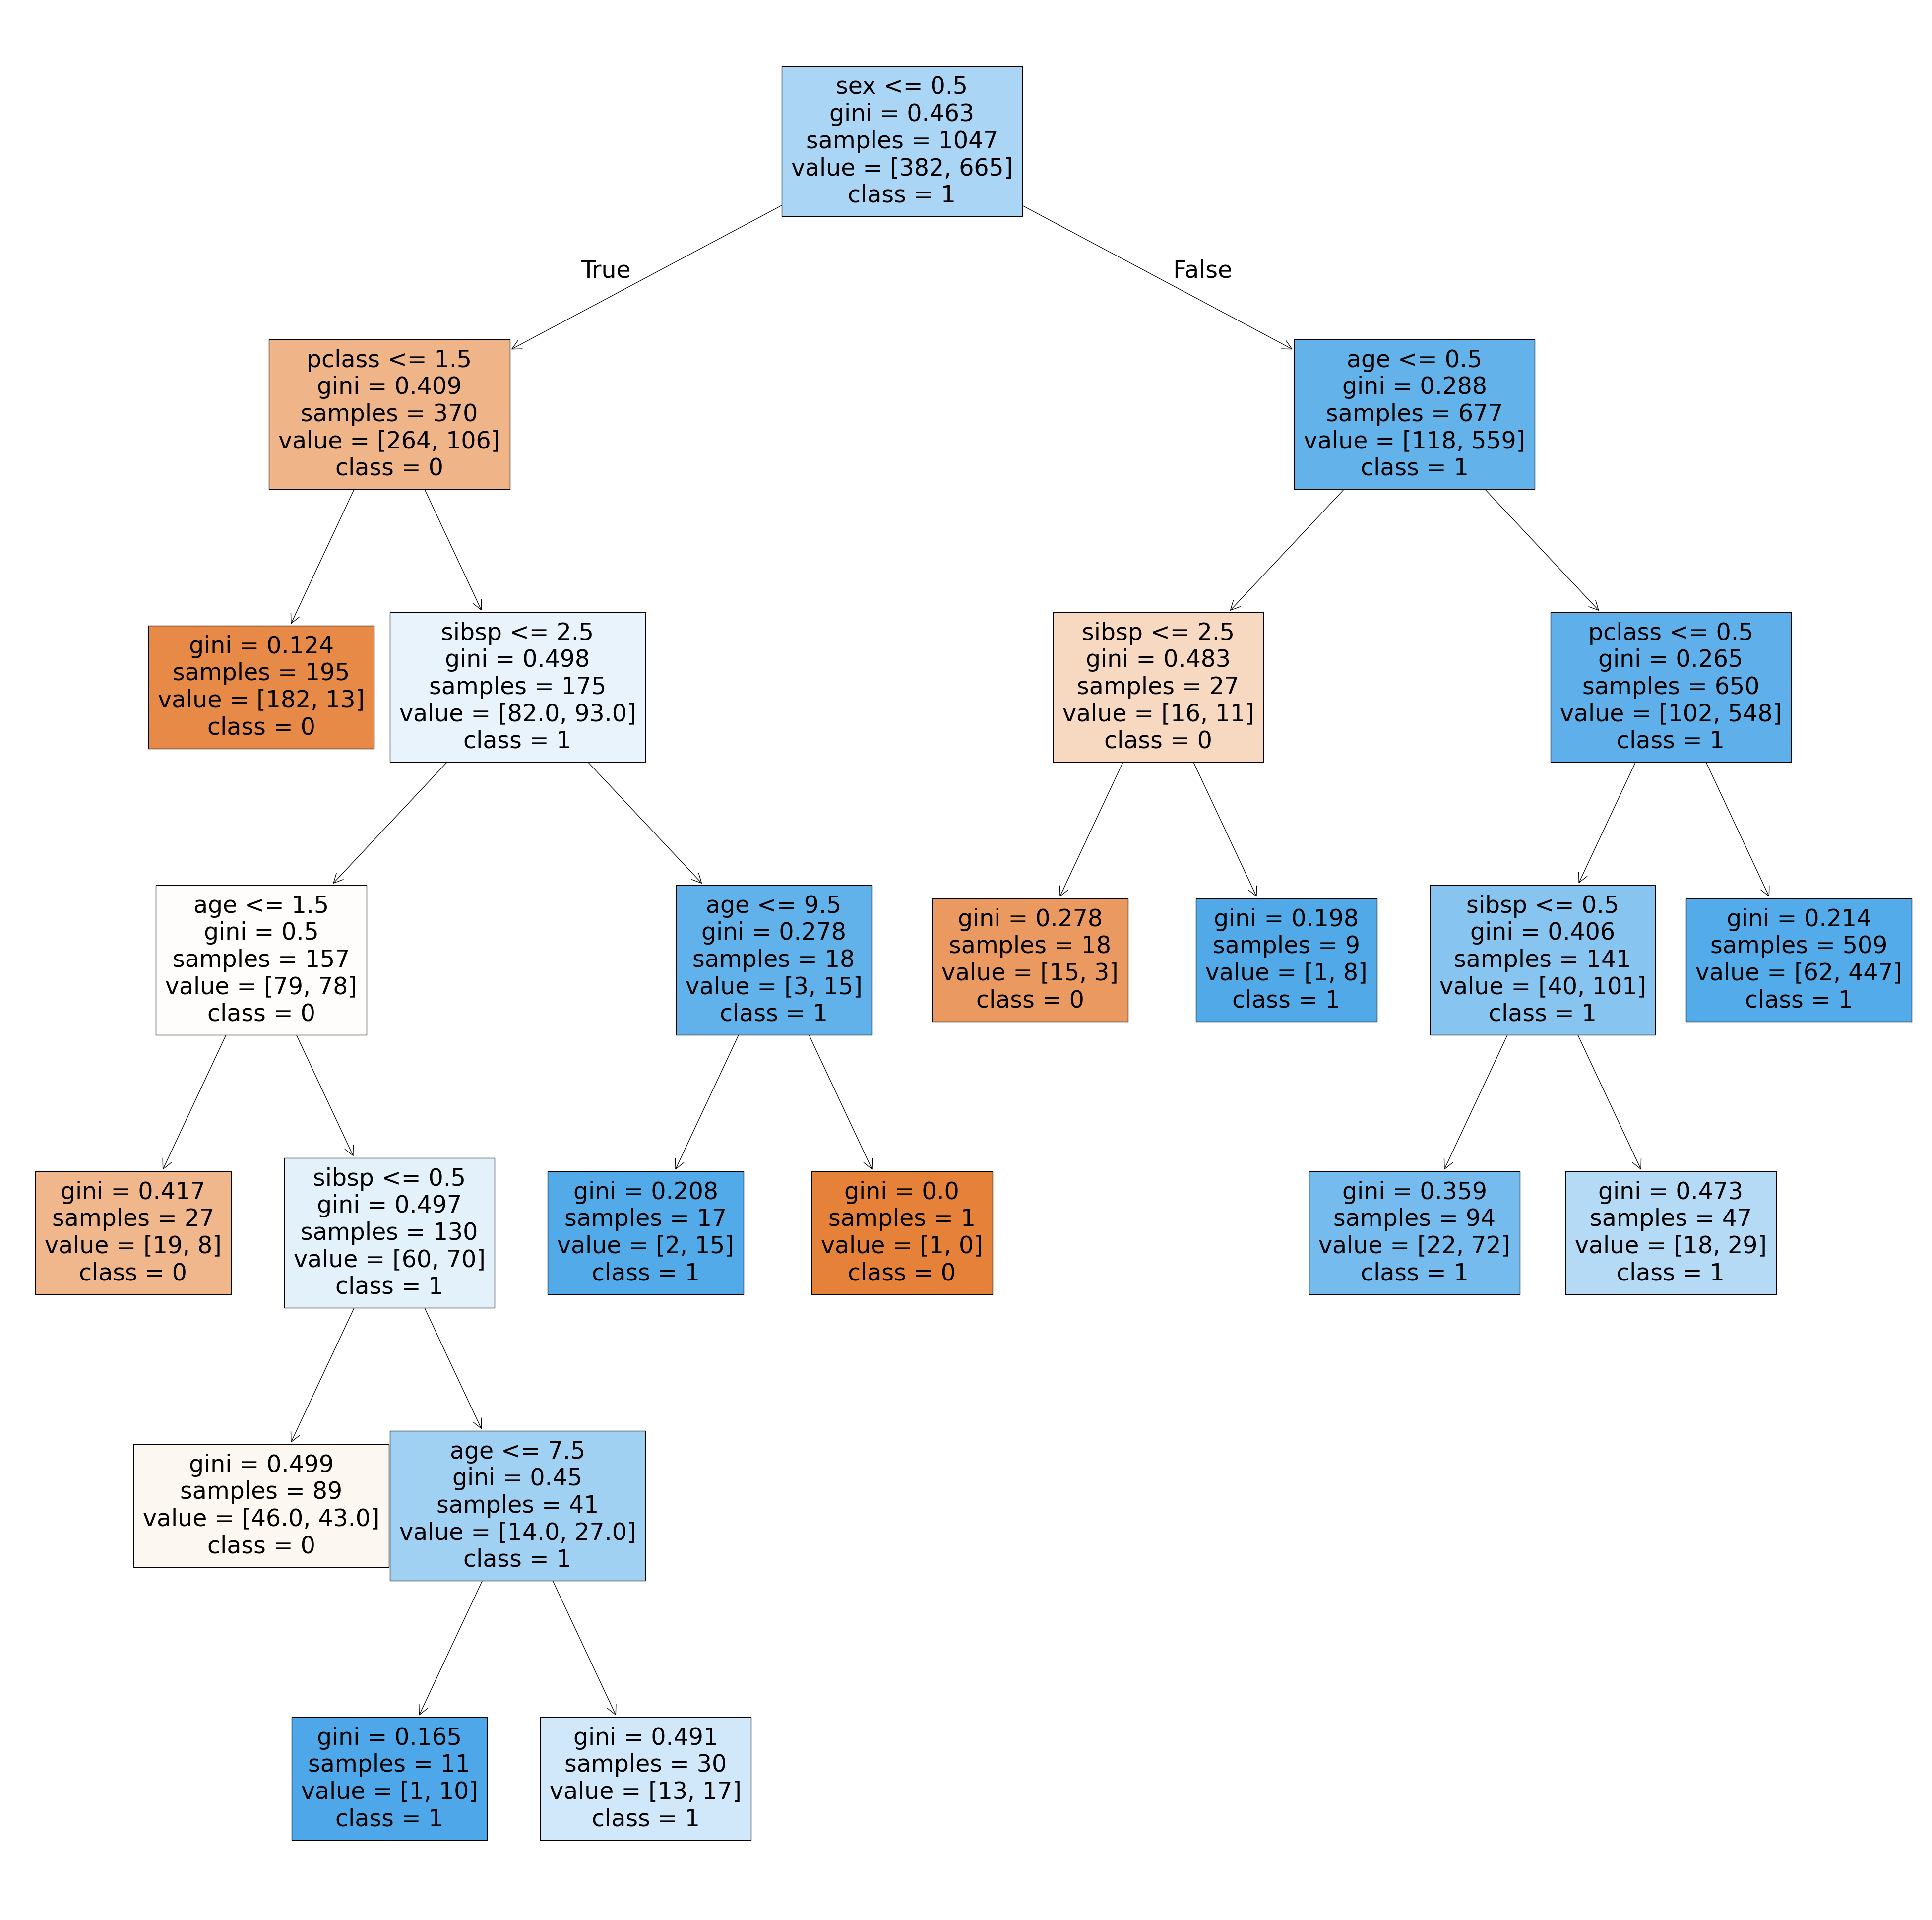

In [67]:
from sklearn.model_selection import GridSearchCV

# Define a range of max_leaf_nodes values to search
param_grid = {'max_leaf_nodes': list(range(5, 20))}

# Run grid search with cross-validation
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=20034297), param_grid, cv=5)
grid_search.fit(X_train, y_train) # Note testing set cannot be used

# Get the best estimator with the optimal max_leaf_nodes parameter
grid_search.best_estimator_

# Get the best value of 'max_leaf_nodes' from the estimator
best_max_leaf_nodes = grid_search.best_params_['max_leaf_nodes']

# Instantiate the DecisionTreeClassifier with optimized max_leaf_nodes value
clf_best = DecisionTreeClassifier(max_leaf_nodes = best_max_leaf_nodes, random_state = 20034297)

# Get the predictions for the test dataset
clf_best.fit(X_train, y_train)

# Predict the values of test dataset
y_pred_best = clf_best.predict(X_test)

# Plot the pruned decision tree
fig = plt.figure(figsize=(50,50))
plot_tree(clf_best, feature_names = list(X_train.columns), class_names = ['0', '1'], filled = True)


In [68]:
# Get the confusion matrix for the predictions
confusion_matrix(y_test, y_pred_best)

,Predicted Negative,Predicted Positive
Actual Negative,71,47
Actual Positive,17,127


In [69]:
# Get the accuracy score for the predictions
accuracy(y_test, y_pred_best)

0.7557251908396947

In [70]:
# Get the precision score for the predictions
precision(y_test, y_pred_best)

0.7298850574712644

In [71]:
# Get the recall score for the predictions
recall(y_test, y_pred_best)

0.8819444444444444

In [72]:
# Get the F1 score for the predictions
F1(y_test, y_pred_best)

0.7987421383647799

# Step 5


[Text(0.4666666666666667, 0.9285714285714286, 'sex <= 0.5\ngini = 0.463\nsamples = 1047\nvalue = [382, 665]\nclass = 1'),
 Text(0.2, 0.7857142857142857, 'pclass <= 1.5\ngini = 0.409\nsamples = 370\nvalue = [264, 106]\nclass = 0'),
 Text(0.33333333333333337, 0.8571428571428572, 'True  '),
 Text(0.13333333333333333, 0.6428571428571429, 'gini = 0.124\nsamples = 195\nvalue = [182, 13]\nclass = 0'),
 Text(0.26666666666666666, 0.6428571428571429, 'sibsp <= 2.5\ngini = 0.498\nsamples = 175\nvalue = [82.0, 93.0]\nclass = 1'),
 Text(0.13333333333333333, 0.5, 'age <= 1.5\ngini = 0.5\nsamples = 157\nvalue = [79, 78]\nclass = 0'),
 Text(0.06666666666666667, 0.35714285714285715, 'gini = 0.417\nsamples = 27\nvalue = [19, 8]\nclass = 0'),
 Text(0.2, 0.35714285714285715, 'sibsp <= 0.5\ngini = 0.497\nsamples = 130\nvalue = [60, 70]\nclass = 1'),
 Text(0.13333333333333333, 0.21428571428571427, 'gini = 0.499\nsamples = 89\nvalue = [46.0, 43.0]\nclass = 0'),
 Text(0.26666666666666666, 0.21428571428571427,

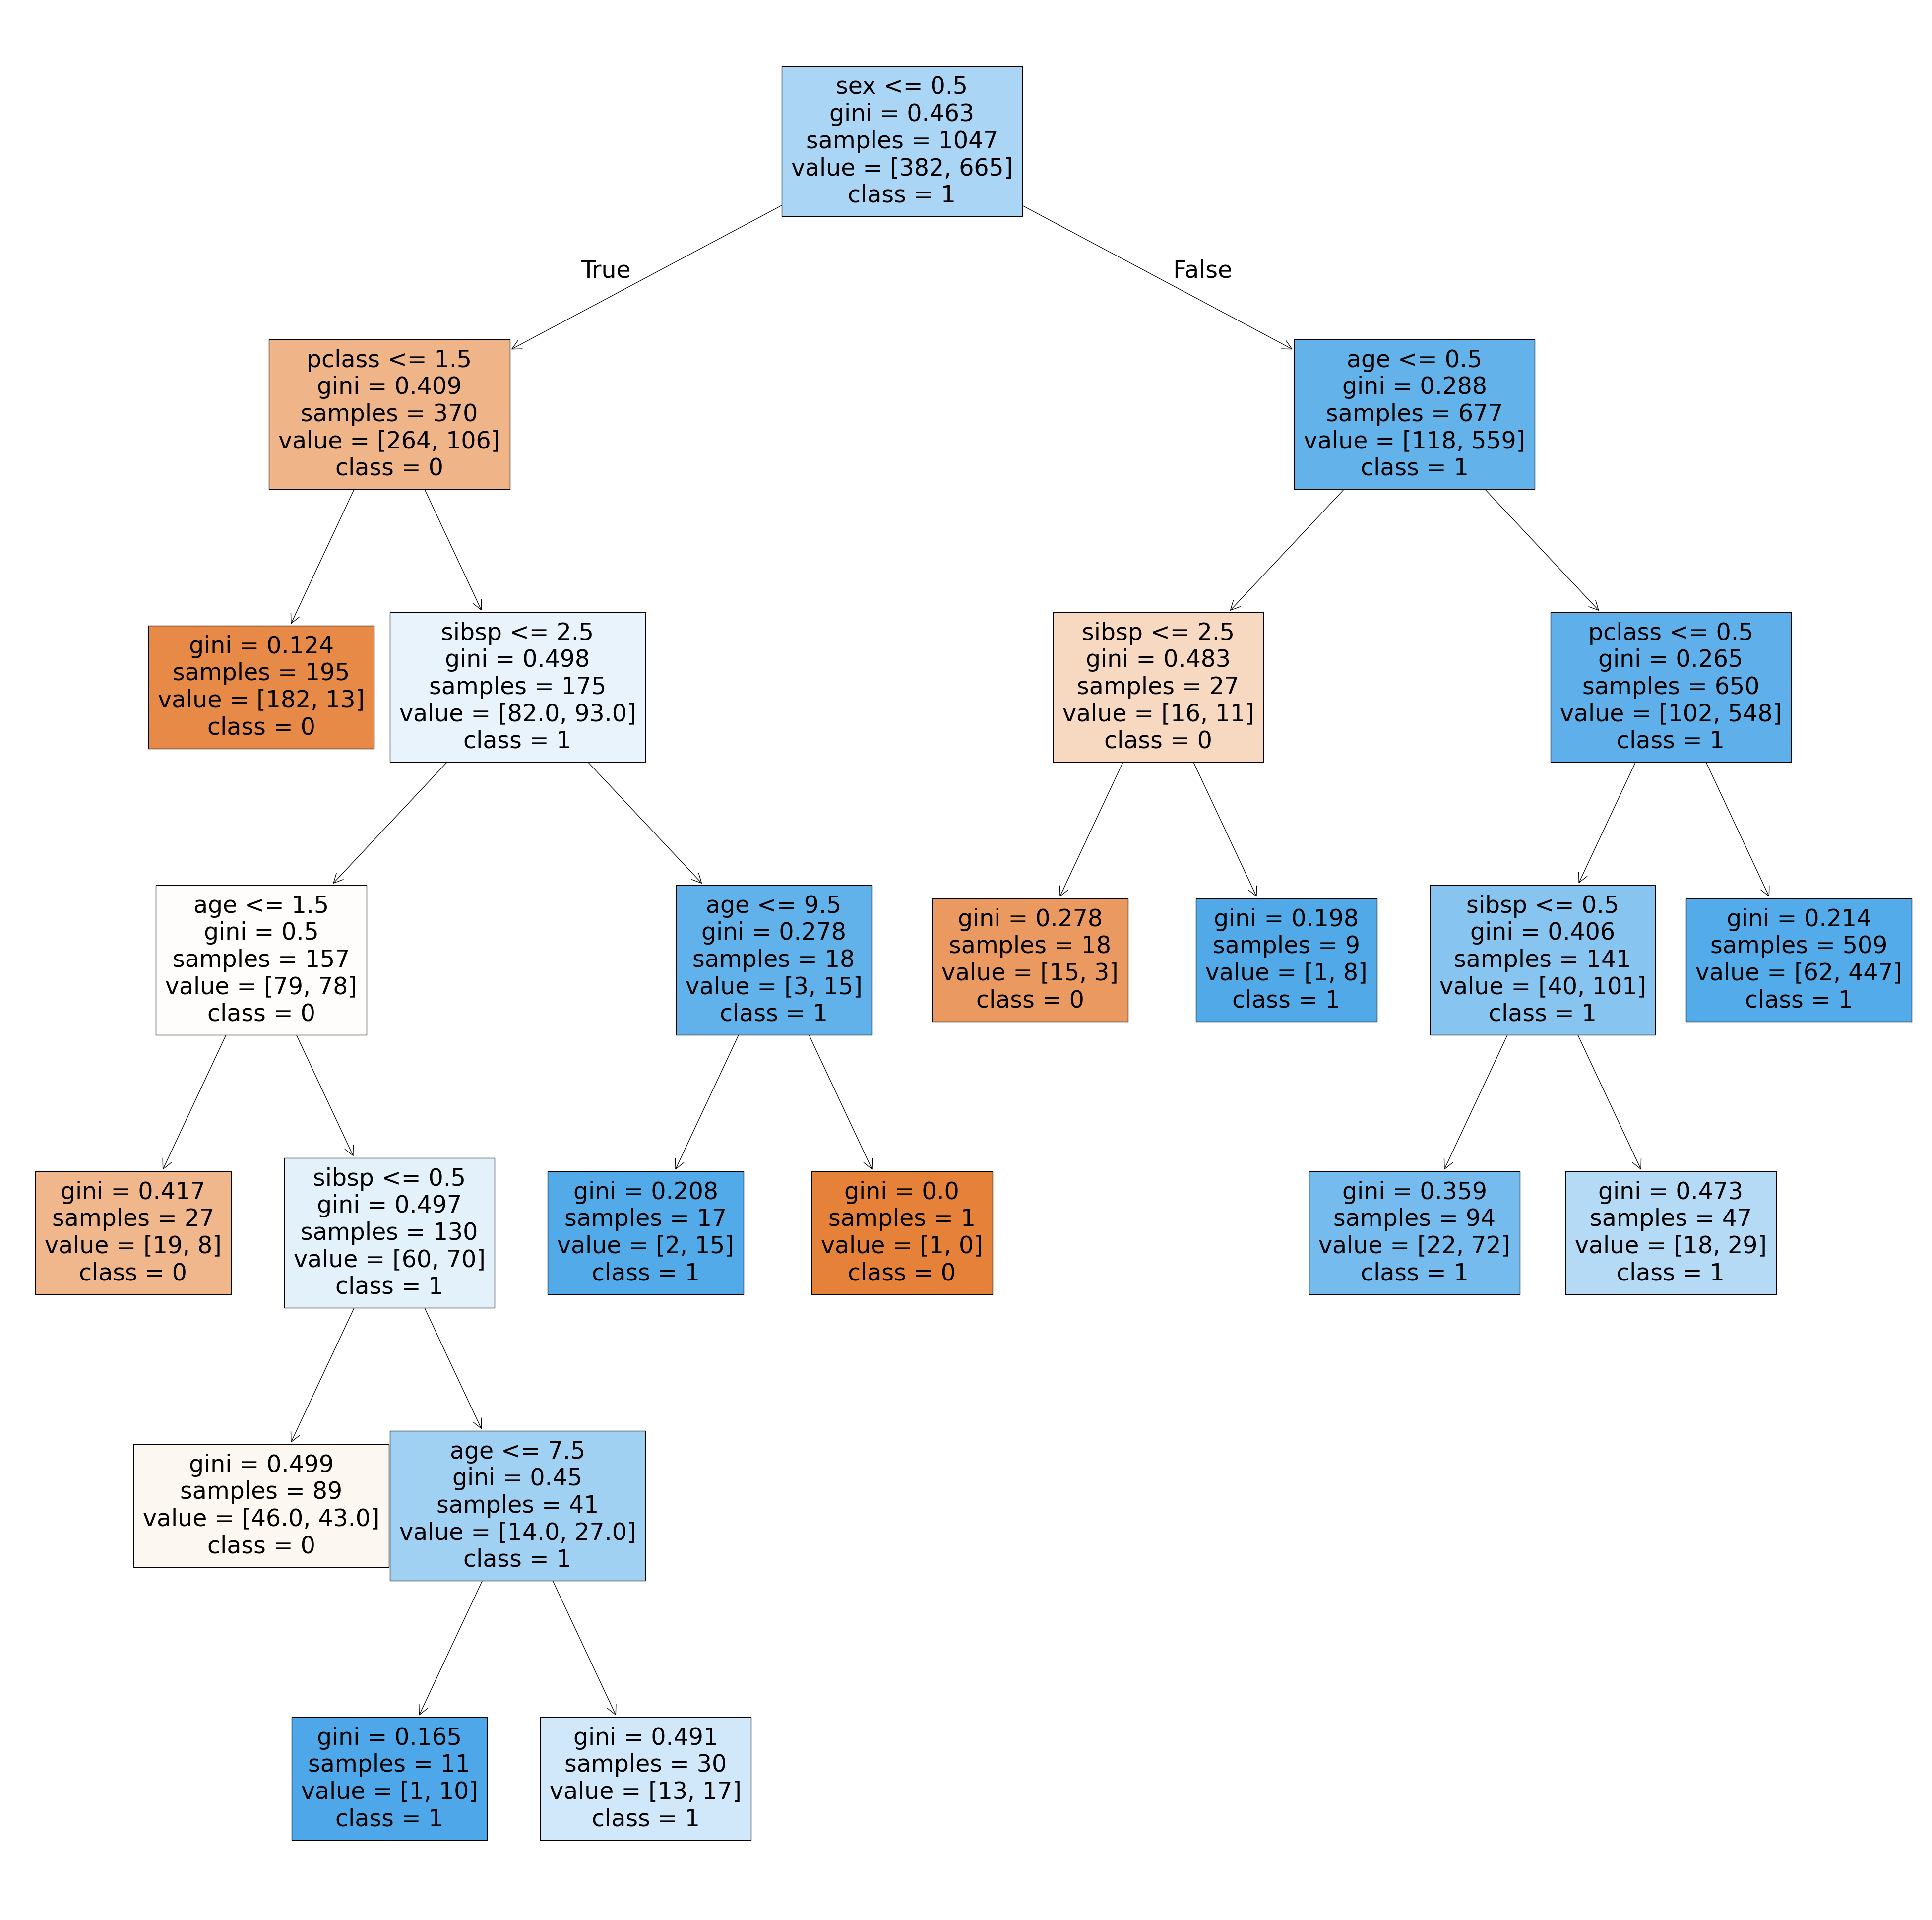

In [73]:
## it's an example (max_depth)
# Instantiate a decision tree with the best max_leaf_nodes parameter
best_tree = DecisionTreeClassifier(max_leaf_nodes = best_max_leaf_nodes, random_state = 20034297)

# Train the decision tree on training data
best_tree.fit(X_train, y_train)

# Plot the tree
fig = plt.figure(figsize=(50,50))
plot_tree(best_tree, feature_names = list(X_train.columns), class_names = ['0', '1'], filled = True)

[Text(0.43148474178403756, 0.9444444444444444, 'sex <= 0.5\ngini = 0.463\nsamples = 1047\nvalue = [382, 665]\nclass = 1'),
 Text(0.2221244131455399, 0.8333333333333334, 'pclass <= 1.5\ngini = 0.409\nsamples = 370\nvalue = [264, 106]\nclass = 0'),
 Text(0.32680457746478875, 0.8888888888888888, 'True  '),
 Text(0.07276995305164319, 0.7222222222222222, 'pclass <= 0.5\ngini = 0.124\nsamples = 195\nvalue = [182, 13]\nclass = 0'),
 Text(0.018779342723004695, 0.6111111111111112, 'age <= 0.5\ngini = 0.068\nsamples = 113\nvalue = [109, 4]\nclass = 0'),
 Text(0.009389671361502348, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = 1'),
 Text(0.028169014084507043, 0.5, 'age <= 5.5\ngini = 0.052\nsamples = 112\nvalue = [109, 3]\nclass = 0'),
 Text(0.018779342723004695, 0.3888888888888889, 'gini = 0.0\nsamples = 28\nvalue = [28, 0]\nclass = 0'),
 Text(0.03755868544600939, 0.3888888888888889, 'age <= 6.5\ngini = 0.069\nsamples = 84\nvalue = [81, 3]\nclass = 0'),
 Text(0.018779342723004695, 0.277

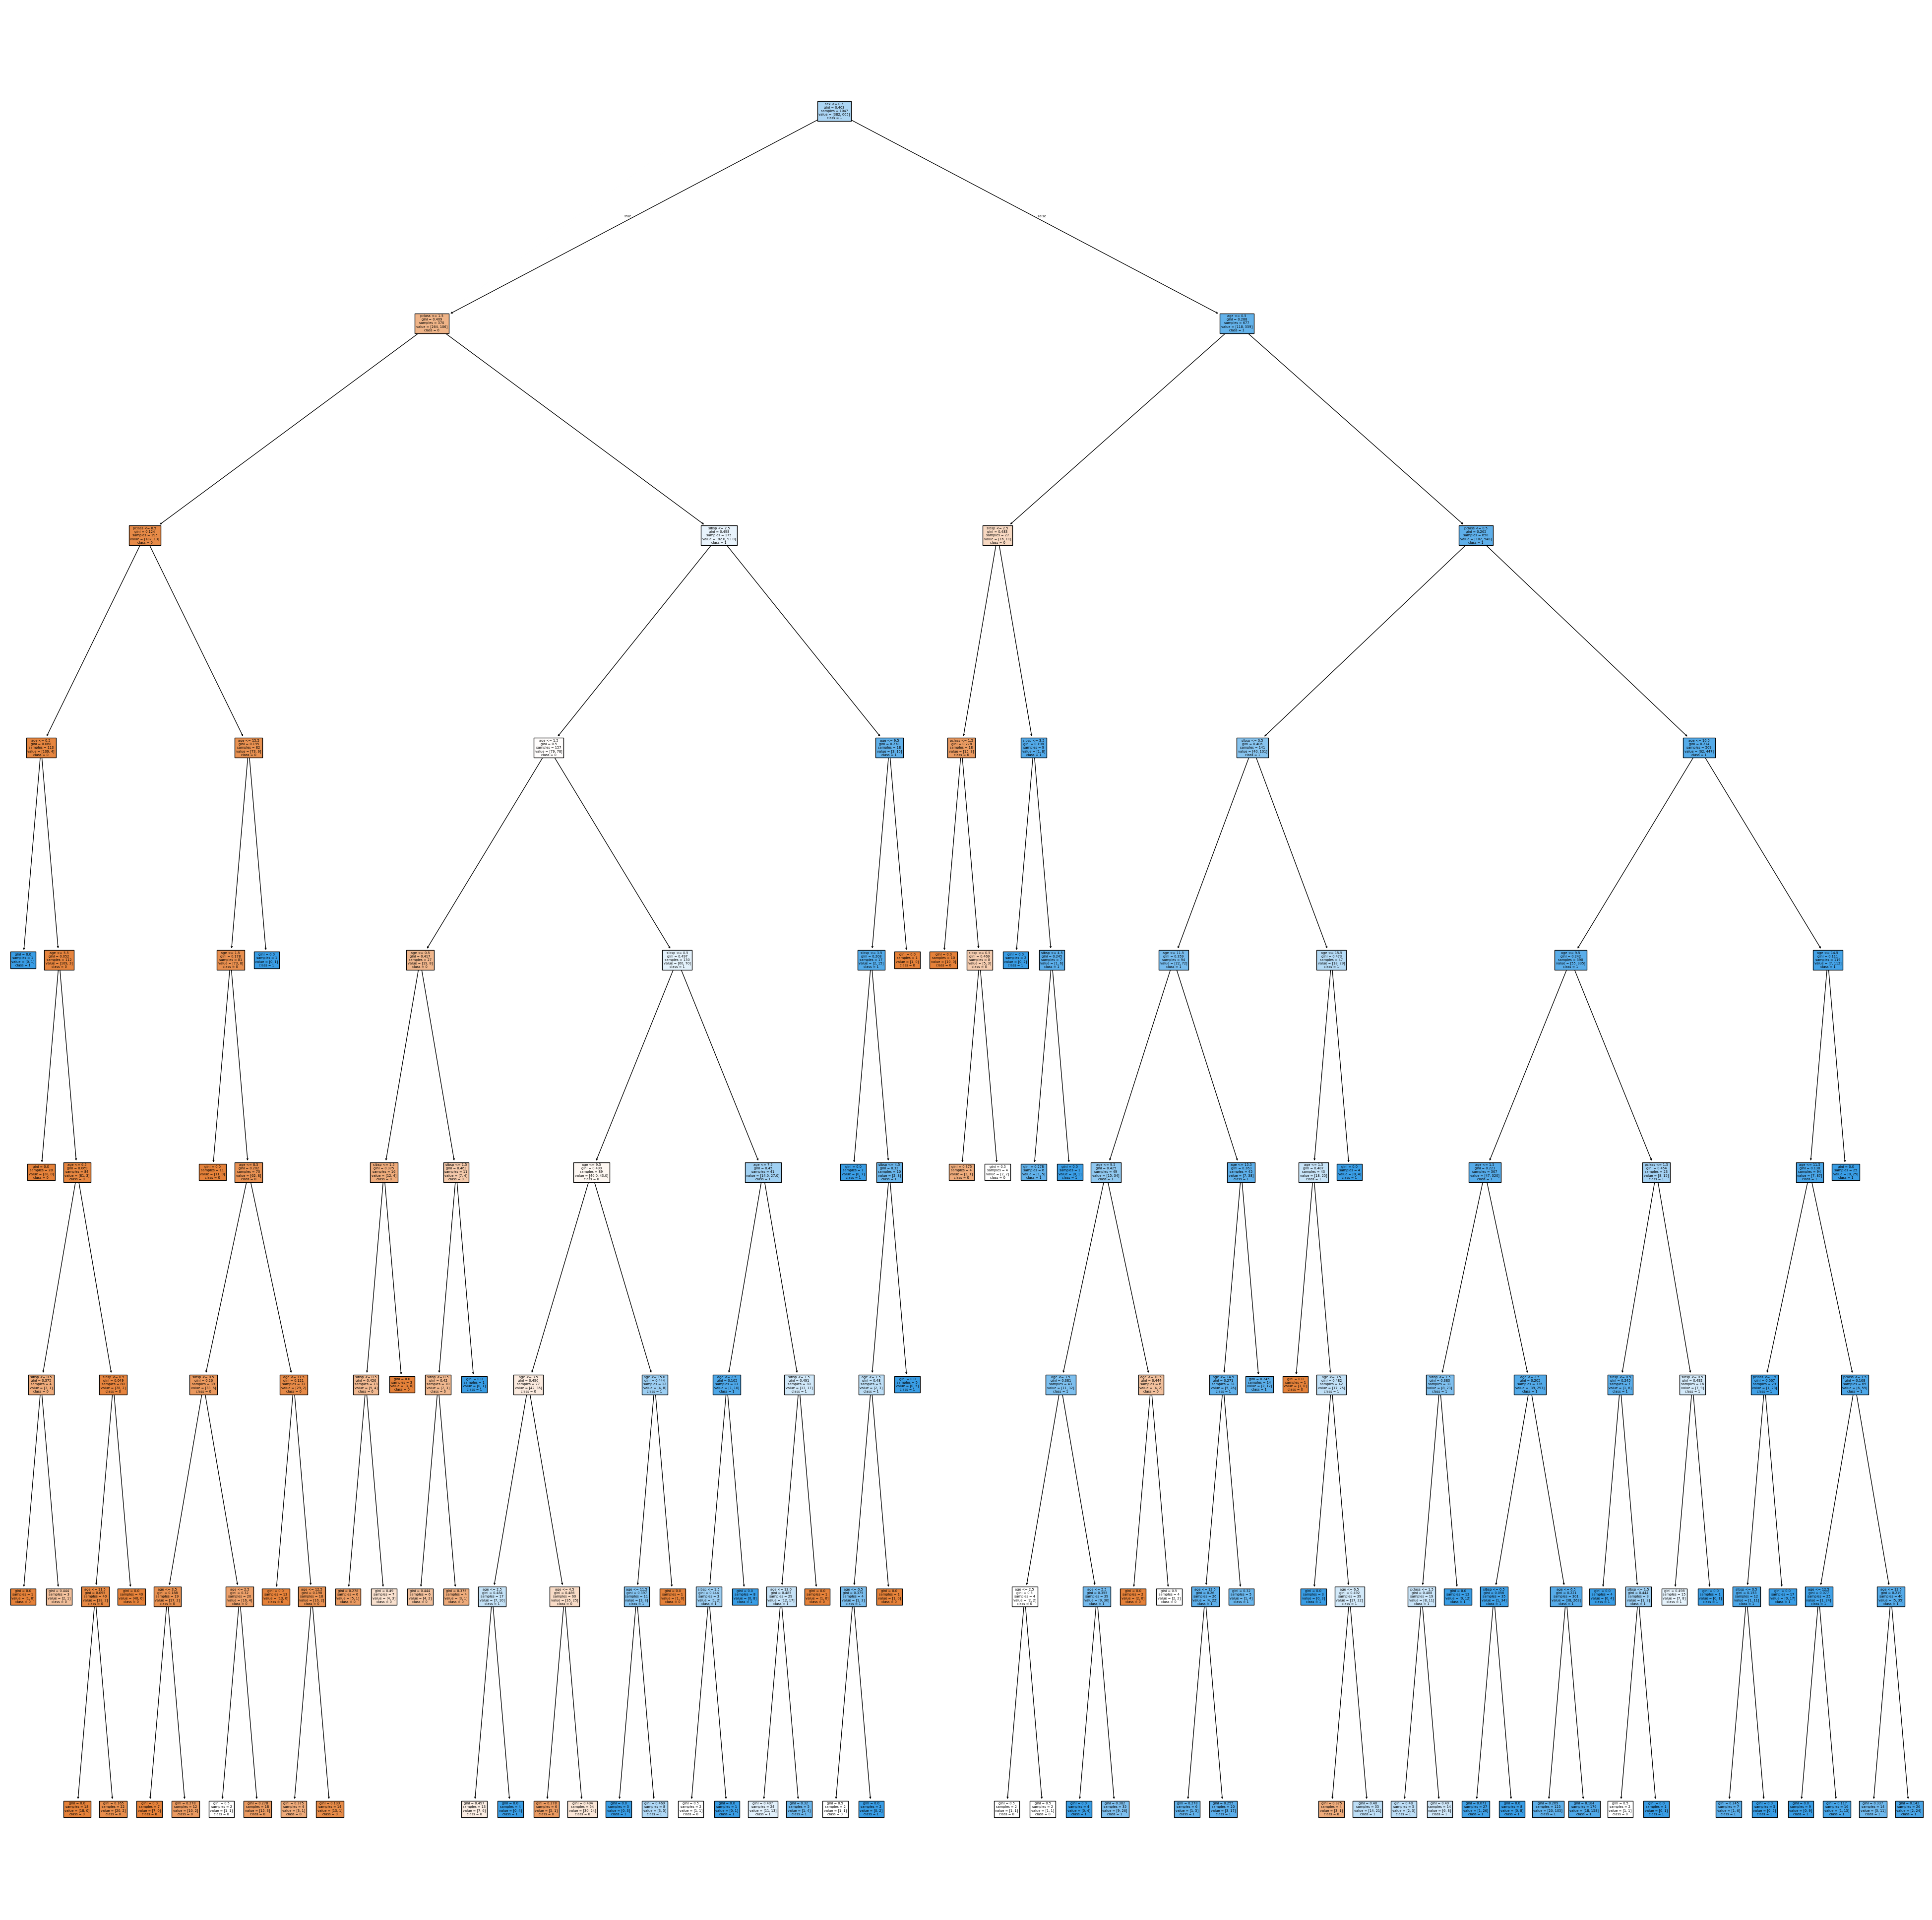

In [74]:
# Instantiate a decision tree with the a max_depth parameter
dt_max_depth = DecisionTreeClassifier(max_depth = 8, random_state = 20034297)

# Train the decision tree on training data
dt_max_depth.fit(X_train, y_train)

# Plot the tree
fig = plt.figure(figsize=(50,50))
plot_tree(dt_max_depth, feature_names = list(X_train.columns), class_names = ['0', '1'], filled = True)

[Text(0.4944271534320323, 0.9642857142857143, 'sex <= 0.27\nentropy = 0.947\nsamples = 1047\nvalue = [382, 665]\nclass = 1'),
 Text(0.22081090174966353, 0.8928571428571429, 'pclass <= 1.207\nentropy = 0.864\nsamples = 370\nvalue = [264, 106]\nclass = 0'),
 Text(0.3576190275908479, 0.9285714285714286, 'True  '),
 Text(0.09757738896366083, 0.8214285714285714, 'pclass <= 0.907\nentropy = 0.353\nsamples = 195\nvalue = [182, 13]\nclass = 0'),
 Text(0.03633916554508748, 0.75, 'age <= 2.89\nentropy = 0.221\nsamples = 113\nvalue = [109, 4]\nclass = 0'),
 Text(0.016150740242261104, 0.6785714285714286, 'age <= 1.872\nentropy = 0.371\nsamples = 14\nvalue = [13, 1]\nclass = 0'),
 Text(0.010767160161507403, 0.6071428571428571, 'age <= 0.826\nentropy = 0.65\nsamples = 6\nvalue = [5, 1]\nclass = 0'),
 Text(0.005383580080753701, 0.5357142857142857, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = 1'),
 Text(0.016150740242261104, 0.5357142857142857, 'entropy = 0.0\nsamples = 5\nvalue = [5, 0]\nclas

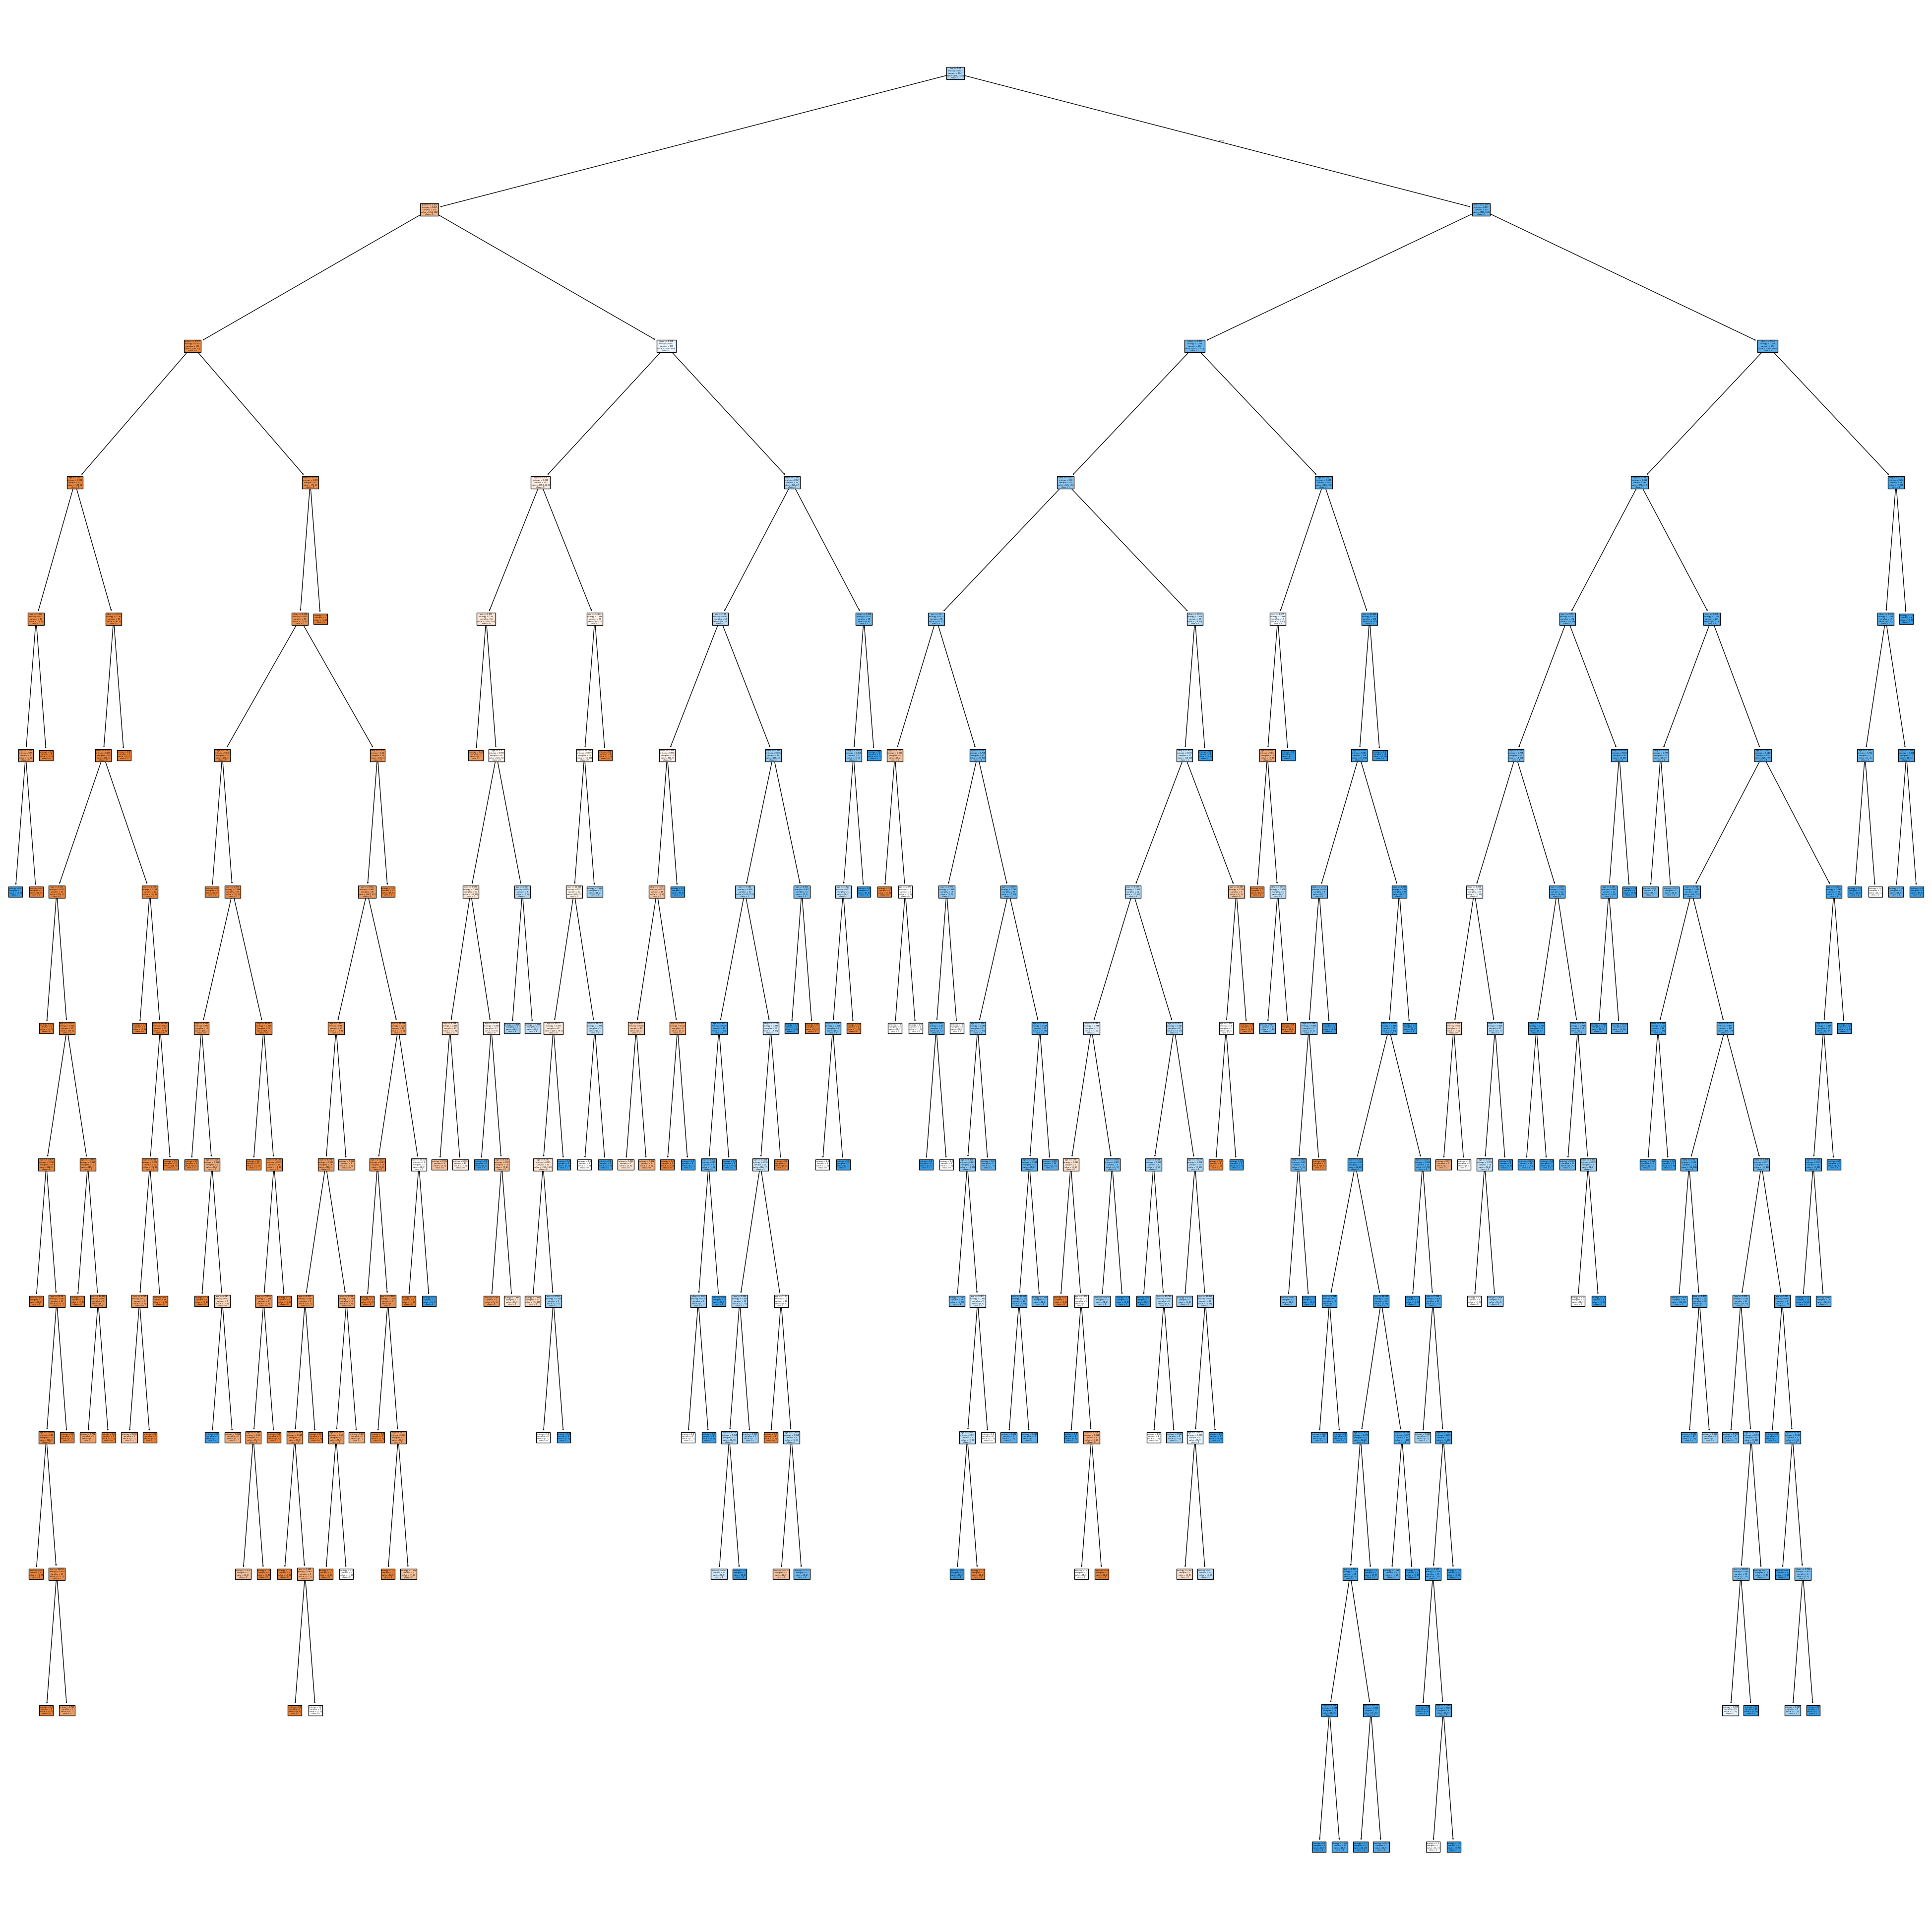

In [75]:
# Instantiate a decision tree with entropy as splitting criteria parameter
dt_opt_critia = DecisionTreeClassifier(criterion = 'entropy', splitter = 'random', random_state = 20034297)

# Train the decision tree on training data
dt_opt_critia.fit(X_train, y_train)

# Plot the tree
fig = plt.figure(figsize=(50,50))
plot_tree(dt_opt_critia, feature_names = list(X_train.columns), class_names = ['0', '1'], filled = True)

In [76]:
def ensemble_vote(models, X):

    # Perform majority vote
    # For each sample, count the votes for each class (0 or 1)

    # Determine the winning class for each sample: it's the one with the most votes
    # If there's a tie, we choose the class with the highest index (1 in this case)
    predicts = []

    # Store the models
    for m in models :
      predicts.append(m.predict(X))

    # Store the predictions that are voted the highest
    ensemble_predictions = []

    # Iterate thoughout the three model's results with the given conditions of vote
    for i in range(len(X)) :
      vote = []
      for j in range(len(models)) :
        vote.append(predicts[j][i])

      if vote.count(1) >= vote.count(0) :
        ensemble_predictions.append(1)

      if vote.count(1) < vote.count(0) :
        ensemble_predictions.append(0)

    return ensemble_predictions

# Use the defined function to get predictions from the ensemble of the three trees
models = [best_tree, dt_max_depth, dt_opt_critia]
ensemble_predictions = ensemble_vote(models, X_test)

# Calculate performance metrics for the ensemble using the previously defined function


In [77]:
# Get the confusion matrix for the predictions
confusion_matrix(y_test, ensemble_predictions)

,Predicted Negative,Predicted Positive
Actual Negative,74,44
Actual Positive,21,123


In [78]:
# Get the accuracy score for the predictions
accuracy(y_test, ensemble_predictions)

0.7519083969465649

In [79]:
# Get the precision score for the predictions
precision(y_test, ensemble_predictions)

0.7365269461077845

In [80]:
# Get the recall score for the predictions
recall(y_test, ensemble_predictions)

0.8541666666666666

In [81]:
# Get the F1 score for the predictions
F1(y_test, ensemble_predictions)

0.7909967845659164

In [82]:
# Train a random forest model using the optimal tree you found in step 4 and compare the ensembled model with the random forest 
from sklearn.ensemble import RandomForestClassifier

# Instantiate a Random Forest Classifier
rf = RandomForestClassifier(n_estimators = 50, max_leaf_nodes = best_max_leaf_nodes, random_state = 20034297)

# Train the model on traing data
rf.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_leaf_nodes=12, n_estimators=50,
                       random_state=20034297)

In [83]:
# Get the predictions of the Random Forest Model
y_rf_pred = rf.predict(X_test)

In [84]:
# Get the confusion matrix for the predictions
confusion_matrix(y_test, y_rf_pred)

,Predicted Negative,Predicted Positive
Actual Negative,67,51
Actual Positive,13,131


In [85]:
# Get the accuracy score for the predictions
accuracy(y_test, y_rf_pred)

0.7557251908396947

In [86]:
# Get the precision score for the predictions
precision(y_test, y_rf_pred)

0.7197802197802198

In [87]:
# Get the recall score for the predictions
recall(y_test, y_rf_pred)

0.9097222222222222

In [88]:
# Get the F1 score for the predictions
F1(y_test, y_rf_pred)

0.803680981595092